In [1]:
import pandas as pd
import numpy as np
import string
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df = pd.read_csv("J:/Data science/data/NLP/E_mail messages.csv")

In [3]:
df.head()

,label,body_text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

## Text Preprocessing

In [6]:
stop_words_list = nltk.corpus.stopwords.words("english")

In [7]:
porter = nltk.PorterStemmer()

In [8]:
lemma_nltk = WordNetLemmatizer()

In [9]:
def clean_text(text):
    text = "".join([word.lower() for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    text = " ".join([lemma_nltk.lemmatize(word) for word in tokens if word not in stop_words_list])
    return text

In [10]:
df['cleaned_text'] = df['body_text'].apply(lambda x:clean_text(x))

In [11]:
df.head(15)

,label,body_text,cleaned_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 week word back id like f...
6,ham,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,spam,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,spam,Had your mobile 11 months or more? U R entitle...,mobile 11 month u r entitled update latest col...


In [12]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [13]:
bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(df['cleaned_text'])

In [14]:
print("sparse matrix..\n" ,bow_matrix)

sparse matrix..
   (np.int32(0), np.int32(3588))	1
  (np.int32(0), np.int32(4431))	1
  (np.int32(0), np.int32(6036))	1
  (np.int32(0), np.int32(2387))	1
  (np.int32(0), np.int32(1377))	1
  (np.int32(0), np.int32(1813))	1
  (np.int32(0), np.int32(3677))	1
  (np.int32(0), np.int32(8577))	1
  (np.int32(0), np.int32(4580))	1
  (np.int32(0), np.int32(1811))	1
  (np.int32(0), np.int32(2123))	1
  (np.int32(0), np.int32(3640))	1
  (np.int32(0), np.int32(1153))	1
  (np.int32(0), np.int32(8358))	1
  (np.int32(1), np.int32(5632))	1
  (np.int32(1), np.int32(4616))	1
  (np.int32(1), np.int32(4401))	1
  (np.int32(1), np.int32(8482))	1
  (np.int32(1), np.int32(5663))	1
  (np.int32(2), np.int32(3394))	1
  (np.int32(2), np.int32(3006))	2
  (np.int32(2), np.int32(8533))	1
  (np.int32(2), np.int32(2231))	1
  (np.int32(2), np.int32(8495))	1
  (np.int32(2), np.int32(3137))	2
  :	:
  (np.int32(5567), np.int32(5529))	1
  (np.int32(5568), np.int32(3958))	1
  (np.int32(5568), np.int32(3604))	1
  (np.int32(5568

In [15]:
array_mat = bow_matrix.toarray()
array_mat

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [16]:
array_mat.shape

(5572, 8841)

In [18]:
dataf = pd.DataFrame(array_mat)
dataf.head()

,0,1,2,3,4,5,6,7,8,9,...,8831,8832,8833,8834,8835,8836,8837,8838,8839,8840
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
bow_matrix.shape

(5572, 8841)

In [20]:
ngram_vec = CountVectorizer(ngram_range=(1,3))
ng_matrix = ngram_vec.fit_transform(df['cleaned_text'])

In [21]:
print("spars matrix is...\n" , ng_matrix)

spars matrix is...
   (np.int32(0), np.int32(24803))	1
  (np.int32(0), np.int32(32958))	1
  (np.int32(0), np.int32(48294))	1
  (np.int32(0), np.int32(14695))	1
  (np.int32(0), np.int32(6501))	1
  (np.int32(0), np.int32(9566))	1
  (np.int32(0), np.int32(26588))	1
  (np.int32(0), np.int32(69736))	1
  (np.int32(0), np.int32(34171))	1
  (np.int32(0), np.int32(9558))	1
  (np.int32(0), np.int32(12414))	1
  (np.int32(0), np.int32(26064))	1
  (np.int32(0), np.int32(4920))	1
  (np.int32(0), np.int32(67202))	1
  (np.int32(0), np.int32(25025))	1
  (np.int32(0), np.int32(32959))	1
  (np.int32(0), np.int32(48309))	1
  (np.int32(0), np.int32(14698))	1
  (np.int32(0), np.int32(6504))	1
  (np.int32(0), np.int32(9570))	1
  (np.int32(0), np.int32(26722))	1
  (np.int32(0), np.int32(69759))	1
  (np.int32(0), np.int32(34172))	1
  (np.int32(0), np.int32(9559))	1
  (np.int32(0), np.int32(12425))	1
  :	:
  (np.int32(5570), np.int32(3579))	1
  (np.int32(5570), np.int32(35742))	1
  (np.int32(5570), np.int32(304

In [22]:
feat_ngram = pd.DataFrame(ng_matrix.toarray())
feat_ngram.head()

,0,1,2,3,4,5,6,7,8,9,...,71869,71870,71871,71872,71873,71874,71875,71876,71877,71878
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])

In [24]:
print("sparse matrix...\n" , tfidf_matrix)

sparse matrix...
   (np.int32(0), np.int32(3588))	0.15513214741241693
  (np.int32(0), np.int32(4431))	0.34907560185633246
  (np.int32(0), np.int32(6036))	0.23835620117783826
  (np.int32(0), np.int32(2387))	0.27033502436761486
  (np.int32(0), np.int32(1377))	0.26544376257683694
  (np.int32(0), np.int32(1813))	0.2949004790583351
  (np.int32(0), np.int32(3677))	0.19429062554759827
  (np.int32(0), np.int32(8577))	0.23722339460099312
  (np.int32(0), np.int32(4580))	0.2949004790583351
  (np.int32(0), np.int32(1811))	0.33323039420193634
  (np.int32(0), np.int32(2123))	0.2949004790583351
  (np.int32(0), np.int32(3640))	0.16214794848884176
  (np.int32(0), np.int32(1153))	0.34907560185633246
  (np.int32(0), np.int32(8358))	0.19903329746163903
  (np.int32(1), np.int32(5632))	0.2741803362458879
  (np.int32(1), np.int32(4616))	0.4080505634471753
  (np.int32(1), np.int32(4401))	0.5233273701797004
  (np.int32(1), np.int32(8482))	0.4313385731102942
  (np.int32(1), np.int32(5663))	0.5462557824449175
  

In [25]:
feat_tfidf = pd.DataFrame(tfidf_matrix.toarray())
feat_tfidf.head()

,0,1,2,3,4,5,6,7,8,9,...,8831,8832,8833,8834,8835,8836,8837,8838,8839,8840
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
feat_tfidf.columns = tfidf.get_feature_names_out()
feat_tfidf.head()

,008704050406,0089my,0121,01223585236,01223585334,0125698789,02,020603,0207,02070836089,...,ìï,ìïll,ûthanks,ûªm,ûªt,ûªve,ûï,ûïharry,ûò,ûówell
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.head()

,label,body_text,cleaned_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [28]:
matrix_tfidf = feat_tfidf.copy()
matrix_tfidf

,008704050406,0089my,0121,01223585236,01223585334,0125698789,02,020603,0207,02070836089,...,ìï,ìïll,ûthanks,ûªm,ûªt,ûªve,ûï,ûïharry,ûò,ûówell
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
x = matrix_tfidf
y = df['label']

In [30]:
from sklearn.model_selection import *

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.33,random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform(x_test)

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
logi_model = LogisticRegression()
logi_model.fit(scaled_x_train,y_train)

LogisticRegression()

In [35]:
y_pred = logi_model.predict(scaled_x_test)
y_pred

array(['ham', 'ham', 'spam', ..., 'ham', 'ham', 'spam'], dtype=object)

In [36]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1585    2]
 [  42  210]]


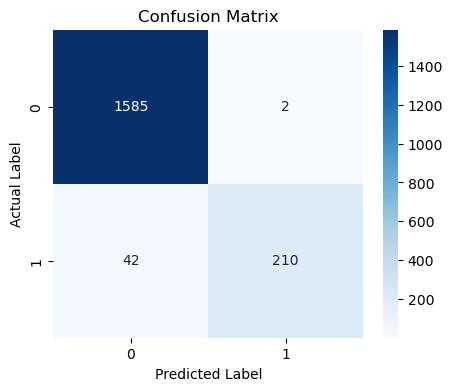

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualize the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

In [39]:
gred_model = GradientBoostingClassifier(n_estimators=30)
gred_model.fit(scaled_x_train,y_train)

GradientBoostingClassifier(n_estimators=30)

In [40]:
y_pred = gred_model.predict(scaled_x_test)
y_pred

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'spam'], dtype=object)

In [41]:
cm2 = confusion_matrix(y_test,y_pred)
cm2

array([[1578,    9],
       [  79,  173]])

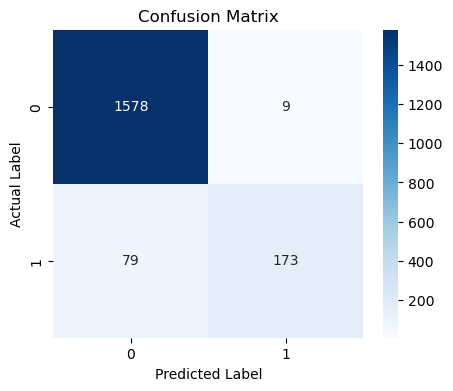

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualize the confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()